## Name: Aryan Mahesh Patil
### Rollno: 46
#### Subject: DL
#### Experiment No: 6

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
transform=transforms.ToTensor()
train_dataset=datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_dataset=datasets.MNIST(root='./data',train=False,download=True,transform=transform)

train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 131MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 22.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 29.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.08MB/s]


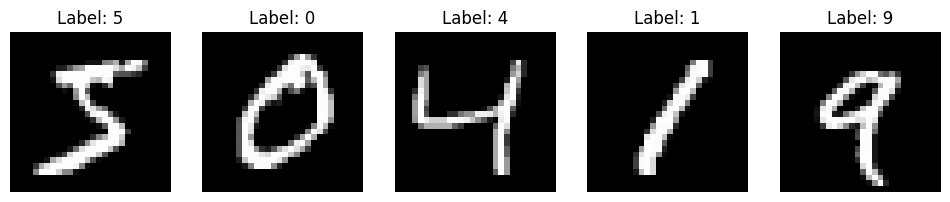

In [ ]:
import matplotlib.pyplot as plt

fig,axes=plt.subplots(1,5,figsize=(12,6))

for i in range(5):
  image, label=train_dataset[i]
  axes[i].imshow(image.squeeze(),cmap='gray')
  axes[i].set_title(f"Label: {label}")
  axes[i].axis('off')
plt.show()

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv=nn.Sequential(
        nn.Conv2d(1,8,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(8,16,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc=nn.Sequential(
        nn.Linear(16*7*7,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )
  def forward(self,x):
    x=self.conv(x)
    x = x.view(x.size(0), -1)
    x=self.fc(x)
    return x
model=CNN()

In [ ]:
criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(
  model.parameters(),
  lr=0.001
)

In [ ]:
epochs=5
for epoch in range(epochs):
  model.train()
  correct=0
  total=0
  running_loss=0
  for images,labels in train_loader:
    outputs=model(images)
    loss=criterion(outputs,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()
    predicted=outputs.argmax(dim=1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()

  train_accuracy=100*correct/total
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
      for images,labels in test_loader:
        output=model(images)
        predicted=output.argmax(dim=1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()
      test_accuracy=100*correct/total
      print(f"""Epoch: {epoch+1}
Loss: {running_loss/len(train_loader):.4f}
Train Accuracy: {train_accuracy:.4f}
Testing Accuracy: {test_accuracy:.4f}""")

Epoch: 1
Loss: 0.3691
Train Accuracy: 88.9217
Testing Accuracy: 96.3400
Epoch: 2
Loss: 0.1069
Train Accuracy: 96.7817
Testing Accuracy: 97.5800
Epoch: 3
Loss: 0.0732
Train Accuracy: 97.7767
Testing Accuracy: 97.6800
Epoch: 4
Loss: 0.0570
Train Accuracy: 98.2400
Testing Accuracy: 98.5600
Epoch: 5
Loss: 0.0465
Train Accuracy: 98.5083
Testing Accuracy: 98.6300
